# システム概要 - 仕様書

## 1. **課題**
- **目標**: FXのトレードを毎日繰り返し、最終日の日本円での資産の最大化。
- **評価**: 当日案内する評価シナリオに提出いただいた最初の5回の最大。

---

## 2. **条件**
- **初期資産**: 1,000,000円
- **トレード頻度**: 平日に一日一度、FXレートを基に貨幣の取引が可能。
- **取引可能な通貨**: JPY, USD, EUR, AUD, HKD
- **評価方法**: 最終日に全資産をJPYに変換し、その価値を評価。

---

## 3. **問題セット**
各問題セットでは、以下の情報が提供されます：
- **シナリオ名**: Scenario name
- **取引開始日**: Start Date
- **取引終了日**: End Date

問題セット:
- テスト用
  - TEST0: 2016-01-04 ～ 2016-01-11
  - TEST1: 2017-01-04 ～ 2017-01-11
  - TEST2: 2018-01-04 ～ 2018-01-11
  - TEST3: 2019-01-04 ～ 2019-01-11
  - Jan_Mar_2016: 2016-01-04 ～ 2016-03-30
  - Jun_Aug_2016: 2016-06-01 ～ 2016-08-31
  - Feb_Apr_2018: 2018-02-01 ～ 2018-04-28
  - Jun_Aug_2018: 2018-06-01 ～ 2018-08-31
  - Feb_Apr_2019: 2019-02-01 ～ 2019-04-28
  - Jun_Aug_2019: 2019-06-01 ～ 2019-08-31
  - Feb_Apr_2020: 2020-02-01 ～ 2020-04-28
  - Jun_Aug_2020: 2020-06-01 ～ 2020-08-31

- 本番用:
  - Feb_Apr_2017: 2017-02-01 ～ 2017-04-28
  - Jun_Aug_2017: 2017-06-01 ～ 2017-08-31


当日皆様にお配りするuserIdを用いないと、問題セットに対するセッションを開始することはできません。

---

## 4. **（参考） API 概要**
APIに関する詳細が知りたい場合は本セクションをご覧ください．
<details><summary>API概要</summary>

システムは以下のAPIを使用してトレードセッションを管理します。

1. **セッション開始**:
   - **概要**: 指定されたシナリオとUserIdに基づいて、トレードセッションを開始します。
   - **エンドポイント**: `POST /api/trade/start/<scenario>/<userId>`
   - **userId**: userIdは皆さんにご入場の際にお配りした6文字をお使いください。
   - **currentDate**: 現在の日付
   - **jpyBalance**: 現在の日本円での資産。
   - **currentcyToBalance**: 現在のそれぞれの貨幣の資産の量
   - **currentDateRate**: 現在の日付の為替レート
   - **complete**: セッションが終了しているかどうかを表すフラグ
   - **レスポンス例**:
     ```json
     {
       "sessionId": 0,
       "startDate": "2016-01-04",
       "endDate": "2016-01-11",
       "currentDate": "2016-01-04",
       "jpyBalance": 1000000,
       "currencyToBalance": {
         "JPY": 1000000
       },
       "currentDateRates": {
         "USD/JPY": 120.4,
         "EUR/JPY": 130.59
       },
       "complete": false
     }
     ```

2. **取引の実行**:
   - **概要**: セッションの現在日付において、指定された取引を実行します。取引は最終日まで繰り返されます。指定した量の貨幣をcurrencyFromからcurrencyToへ、為替レートcurrentDateRatesを使って変換します。
   
   - **エンドポイント**: `POST /api/trade/next`
   - **リクエスト例**:
     ```json
     {
       "sessionId": 0,
       "exchangeRequests": [
         {
           "currencyFrom": "JPY",
           "currencyTo": "USD",
           "amount": 1000
         },
         {
           "currencyFrom": "JPY",
           "currencyTo": "AUD",
           "amount": 1000
         }
       ]
     }
     ```
   - **レスポンス例**:
   - レスポンスは`POST /api/trade/start/<scenario>/<userId>`と同様だが、currencyToBalanceが先ほどのリクエストに基づいて変更され、currentDateは翌日に、currentDateRatesが翌日の為替レートに、jpyBalanceが翌日の為替レートと現在の保有資産に基づいてアップデートされている。
     ```json
     {
       "sessionId": 0,
       "startDate": "2016-01-04",
       "endDate": "2016-01-11",
       "currentDate": "2016-01-05",
       "jpyBalance": 999969.0392754745,
       "currencyToBalance": {
         "JPY": 998000,
         "USD": 8.30564784053156,
         "AUD": 11.415525114155253
       },
       "currentDateRates": {
         "USD/JPY": 119.27,
         "EUR/JPY": 129.17
       },
       "complete": false
     }
     ```
    - これをcurrentDate == endDate になるまで繰り返す。その際、complete == trueとなっている。

3. **FxRateの参照**:
   - **エンドポイント**:
     - `GET /api/rate/{date}`:
   - **レスポンス例**:
     ```json
     {
         "USD/JPY": 120.4,
         "EUR/JPY": 130.59
     }
     ```
**その他詳細**:
- exchangeRequestsのamountが所有資産のcurrencyFromより多い場合、所有資産の全てをcurrencyToに変換する。
- exchangeRequestsのamountが0より小さい場合、requestは無視される。
- rateのAPIは2002-04-01から2023-06-01の間の為替レートを返す。

</details>

---

## 5. **実行**

以下のコード群を上から順に実行することで、セッション開始に必要な事前準備を行うことができます。


自作の Session クラスを実装する際には、BaseTradingSession を継承し、strategy メソッドを override してください。コード群の下部に、サンプルとして FixedStrategySession, ContrarianStrategySession, GoldenCrossStrategySession が提供されています。

詳細は、BaseTradingSession の strategy メソッド部分に記載されたコメントを参照してください。

session.proceed_one_day() を実行すると、strategy メソッドが１度だけ呼ばれ、セッション内部の日付 (self.current_date) が次の日に進みます。session.proceed_to_end() を実行すると、セッションの終了日付になるまで strategy メソッドを繰り返し呼び出します。

---

In [ ]:
# import library
%matplotlib inline
import requests
import copy
import matplotlib.pyplot as plt
import numpy as np
import time
from datetime import datetime, timedelta
from matplotlib import ticker

In [ ]:
# Define common variables
CURRENCY_LIST = ['JPY','USD','AUD','HKD','EUR']
JPY_PAIR_LIST =[currency + '/JPY'  for currency in CURRENCY_LIST if currency != 'JPY']
CURRENCY_PAIR = [f"{currency1}/{currency2}" for currency1 in CURRENCY_LIST for currency2 in CURRENCY_LIST if currency1 != currency2]
BASE_URL = 'http://os3-389-27987.vs.sakura.ne.jp/'
START_URL = BASE_URL + 'api/trade/start/{}/{}'
NEXT_URL = BASE_URL + 'api/trade/next'
RATE_URL = BASE_URL + 'api/rate/{}'

# NOTE: please replace this with your own userId
USER_ID = 'dummy'

# Validation:

######## Don't edit here! ########
if USER_ID == 'dummy':
    raise ValueError("Replace USER_ID with your own userId.")
##################################

In [ ]:
# Define common functions

def generate_last_n_business_days(end: str, n: int) -> list[str]:
    """
    Generate the last n business days (Mon–Fri) ending at `end`.

    Args:
        end: End date in "YYYY-MM-DD" format.
        n: Number of business days to return.

    Returns:
        List of date strings ("YYYY-MM-DD") in chronological order.

    Example:
        >>> generate_last_n_business_days("2025-09-12", 3)
        ['2025-09-10', '2025-09-11', '2025-09-12']
    """
    end_date = datetime.strptime(end, "%Y-%m-%d").date()
    days = []
    current = end_date
    while len(days) < n:
        if current.weekday() < 5:  # Monday=0, Friday=4
            days.append(current)
        current -= timedelta(days=1)
    return list(reversed(days))

def fetch_rates_for_last_n_business_days(end: str, n: int,) -> dict[str, list[float]]:
    """
    Fetch FX rates over the last `n` business days ending at `end` (YYYY-MM-DD).

    Args:
        end: End date in "YYYY-MM-DD" format.
        n: Number of business days to include.

    Returns:
        dict mapping each currency pair to a list of floats aligned by date.

    Example:
        >>> fetch_rates_for_last_n_business_days("2025-09-12", 3)
        {
            'USD/JPY': [147.2, 147.4, 147.8],
            'EUR/JPY': [157.9, 158.1, 158.6],
            ...
        }
    """
    dates = generate_last_n_business_days(end, n)
    result: dict[str, list[float]] = {pair: [] for pair in CURRENCY_PAIR}

    for date in dates:
        rates_for_date = requests.get(RATE_URL.format(date)).json()
        for pair in CURRENCY_PAIR:
            result[pair].append(float(rates_for_date[pair]))

    return result

def append_next_rates(
    currency_pair_to_rates: dict[str, list[float]],
    next_date_rates: dict[str, float]
) -> None:
    """
    Append one day's rates to the existing currency_pair_to_rates dictionary.

    Args:
        currency_pair_to_rates: Existing dictionary {pair: [rates...]}.
        next_date_rates: Dictionary {pair: rate} for the next day.

    Example:
        >>> rates = {
        ...     "USD/JPY": [147.5, 147.8],
        ...     "EUR/JPY": [158.1, 158.4]
        ... }
        >>> append_next_rates(rates, {
        ...     "USD/JPY": 148.0,
        ...     "EUR/JPY": 158.6
        ... })
        >>> rates
        {'USD/JPY': [147.5, 147.8, 148.0],
         'EUR/JPY': [158.1, 158.4, 158.6]}
    """
    for pair in currency_pair_to_rates:
        currency_pair_to_rates[pair].append(float(next_date_rates[pair]))

def generate_pairs_for_quote_currency(quote_currency: str, currency_list: list[str]) -> list[str]:
    """
    Build currency pairs 'BASE/QUOTE' for all currencies except the quote itself.

    Args:
        quote_currency: The currency to be used as the quote (right side).
        currency_list: List of all currencies to consider.

    Returns:
        List of strings representing currency pairs.

    Example:
        >>> generate_pairs_for_quote_currency("JPY", ["USD", "EUR", "JPY"])
        ['USD/JPY', 'EUR/JPY']
    """
    return [f"{base}/{quote_currency}" for base in currency_list if base != quote_currency]


def plot_chart(ax, rates: list[float], today: datetime.date, label: str):
    """
    Plot a series of rates against either recent business days until `today`.

    Args:
        ax: Matplotlib Axes object to plot on.
        rates: list of numeric rate values.
        today: Reference date for calculating recent business days.
        label: Label for the plotted data series.

    Example:
        >>> fig, ax = plt.subplots()
        >>> rates = [1.2, 1.3, 1.25, 1.4]
        >>> plot_chart(ax, rates, today=date(2025, 8, 12), label="USD/JPY")
        >>> ax.legend()
        >>> plt.show()
    """
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    x_values = generate_last_n_business_days(today, len(rates))
    ax.plot(x_values, rates, label=label)

def calc_simple_moving_average(values: list[float], window: int) -> list[float]:
    """
    Calculate the simple moving average (SMA) over a list of numbers.

    For each position i, the average is taken over the last `window` values
    ending at i. If fewer than `window` values are available at the start,
    use the available values.

    Args:
        values: List of numeric values.
        window: Number of points to average (>=1).

    Returns:
        List of SMA values, same length as `values`.

    Example:
        >>> calc_simple_moving_average([1, 2, 3, 4, 5], 3)
        [1.0, 1.5, 2.0, 3.0, 4.0]
    """
    return [
        sum(values[max(0, i - window + 1):i + 1]) / len(values[max(0, i - window + 1):i + 1])
        for i in range(len(values))
    ]

In [ ]:
class BaseTradingSession:
    def __init__(self, test_case, user_id):
        response = requests.post(START_URL.format(test_case, user_id))
        session_info = response.json()  # For details, please refer to "4. API 概要"
        self.session_id = session_info['sessionId']
        self.is_complete = session_info['complete']
        self.start_date = session_info['startDate']
        self.current_date = session_info['currentDate']
        self.currency_to_balance = session_info['currencyToBalance']
        self.currency_pair_to_rates = fetch_rates_for_last_n_business_days(self.start_date, 10)

    def proceed_one_day(self):
        exchange_request_body = self.get_exchange_requests_body()
        if self.is_complete:
            print("already end")
            return
        print('current date:' + self.current_date + ', exchange_requests' + str(exchange_request_body["exchangeRequests"]))
        next_info = self.post_trade_request(exchange_request_body)
        if self.is_complete:
            print(f'JPY: {next_info["jpyBalance"]}')

    def proceed_to_end(self):
        while not self.is_complete:
            self.proceed_one_day()

    def get_exchange_requests_body(self):
        exchange_requests = self.strategy()
        return {
            'sessionId': self.session_id,
            'exchangeRequests': exchange_requests
        }

    def strategy(self):
        """
        Override this method in subclasses to implement a custom trading strategy.

        What to return:
            Return a list of exchange request objects (possibly empty).
            Example return value:
                [
                  {"currencyFrom": "JPY", "currencyTo": "USD", "amount": 1000},
                  {"currencyFrom": "JPY", "currencyTo": "AUD", "amount": 1000}
                ]

        Available instance variables:
            self.is_complete : bool
                Whether the session has finished. If True, no further trades will be processed.
            self.start_date : str
                Session start date (e.g., "2025-08-01"). Useful for backtesting context.
            self.current_date : str
                Current business date of the session (advances after each request).
            self.currency_to_balance : dict[str, float]
                Current balances by currency, e.g. {"JPY": 1000000, "USD": 0.0, ...}.
            self.currency_pair_to_rates : dict[str, list[float]]
                Historical FX rates for recent business days per currency pair.
                Updated each step via `append_next_rates(...)` after a trade request is posted.

        """
        pass

    def post_trade_request(self, request_body_next):
        response = requests.post(NEXT_URL, json=request_body_next)
        next_info = response.json()
        append_next_rates(self.currency_pair_to_rates, next_info['currentDateRates'])
        self.current_date = next_info['currentDate']
        self.currency_to_balance = next_info['currencyToBalance']
        self.is_complete = next_info["complete"]
        return next_info


In [ ]:
# Example of solution
class FixedStrategySession(BaseTradingSession):
    """Example: override `strategy` to define a custom plan."""

    def __init__(self, test_case, user_id):
        super().__init__(test_case, user_id)

    def strategy(self):
        """Fixed daily plan: JPY 1000 → USD, and JPY 1000 → AUD."""
        return [
            {'currencyFrom': 'JPY', 'currencyTo': 'USD', 'amount': 1000},
            {'currencyFrom': 'JPY', 'currencyTo': 'AUD', 'amount': 1000}
        ]

session = FixedStrategySession(test_case="TEST1", user_id=USER_ID)

In [ ]:
# You can use this if you want to execute one by one
session.proceed_one_day()

In [ ]:
# You can use this if you want to execute until the end
session.proceed_to_end()

In [ ]:
# Example of solution (2): a contrarian (逆張り) strategy:
# If a currency held in the portfolio has increased against another currency
# for {x} consecutive days, reallocate {y}% into that currency.
# For instance, if USD/JPY decreases for three consecutive days [130, 129, 128],
# the yen has gained against the dollar, so convert yen into dollars.

CURRENCY_LIST = ['JPY','USD','AUD','HKD','EUR']

class ContrarianStrategySession(BaseTradingSession):
    def __init__(self, test_case, user_id, x, y):
        super().__init__(test_case, user_id)
        self.x = x
        self.y = y

    def strategy(self):
        exchange_requests = []
        for currency, balance in self.currency_to_balance.items():
            if balance > 0:
                currency_pairs = generate_pairs_for_quote_currency(currency, CURRENCY_LIST)
                for currency_pair in currency_pairs:
                    rates = self.currency_pair_to_rates[currency_pair][-self.x:]
                    if all(rates[i] > rates[i + 1] for i in range(len(rates) - 1)):
                        # print(currency_pair + ' rates for past ' + str(self.x) + ' days: ' + str(rates))
                        self.currency_pair_to_exchange = currency_pair
                        exchange_requests.append({
                            'currencyFrom': currency,
                            'currencyTo': currency_pair[:3],
                            'amount': balance * self.y / 100.0
                        })
                        break
        return exchange_requests

session = ContrarianStrategySession(test_case="Jun_Aug_2016", user_id=USER_ID, x=5, y=30)
session.proceed_to_end()


In [ ]:
# Example of solution (3): a Golden Cross / Death Cross strategy:
# Allocate all assets equally across currencies except JPY.
# If the short-term moving average (x-day) rises above the long-term moving average (y-day),
# it is considered an upward trend; if it falls below, it is considered a downward trend.
# In either case, reallocate the assets into that currency.

class GoldenCrossStrategySession(BaseTradingSession):
    def __init__(self, test_case, user_id, x, y):
        super().__init__(test_case, user_id)
        self.x = x
        self.y = y

    def strategy(self):
        exchange_requests = []
        trend = {}
        # Identify currencies with no current positions
        currencies_without_position = [currency for currency, balance in self.currency_to_balance.items() if balance == 0]

        # Calculate trend for each currency
        for currency, balance in self.currency_to_balance.items():
            if currency == 'JPY':
                continue
            currency_pair = currency + '/JPY'
            if sum(self.currency_pair_to_rates[currency_pair][-self.x:])/self.x > sum(self.currency_pair_to_rates[currency_pair][-self.y:])/self.y:
                # Detected upward trend
                if balance == 0:
                    # Allocate JPY to currencies without current positions
                    exchange_requests.append({
                            'currencyFrom': 'JPY',
                            'currencyTo': currency,
                            'amount': self.currency_to_balance['JPY'] / len(currencies_without_position)
                        })
            else:
                # Detected downward trend
                if  balance > 0:
                    # Close existing position
                    exchange_requests.append({
                            'currencyFrom': currency,
                            'currencyTo': 'JPY',
                            'amount': self.currency_to_balance[currency]
                        })
        return exchange_requests

    def draw(self):
      figure, ax = plt.subplots(figsize=(30,10))
      ax.grid()
      currency_pair = 'USD/JPY'
      plot_chart(ax, self.currency_pair_to_rates[currency_pair], today=self.current_date, label=currency_pair)
      plot_chart(ax, calc_simple_moving_average(self.currency_pair_to_rates[currency_pair], self.x), today=self.current_date, label=currency_pair + ' {}DMA'.format(self.x))
      plot_chart(ax, calc_simple_moving_average(self.currency_pair_to_rates[currency_pair], self.y), today=self.current_date, label=currency_pair + ' {}DMA'.format(self.y))
      plt.legend()
      plt.show()


session = GoldenCrossStrategySession(test_case='Jun_Aug_2016', user_id=USER_ID, x=5, y=10)
session.proceed_to_end()

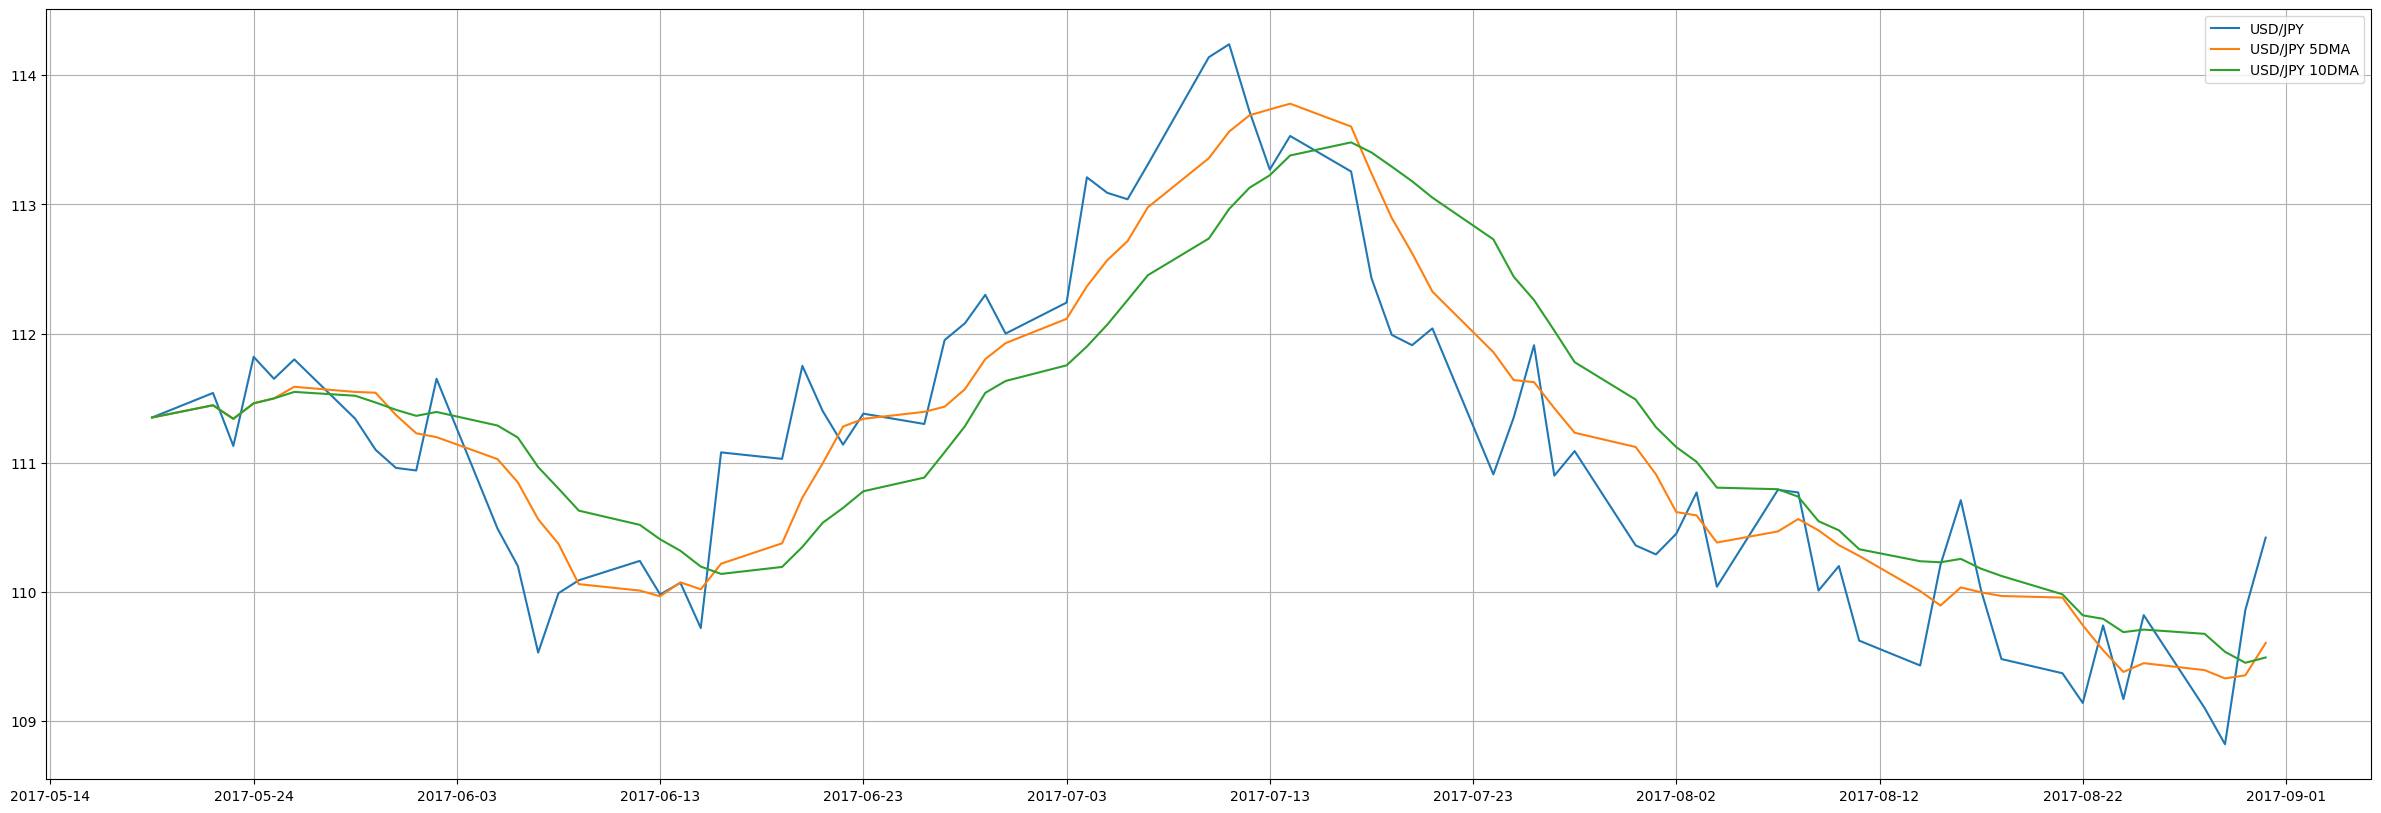

In [ ]:
session.draw()